<a href="https://colab.research.google.com/github/subhashiitb/IITKGP-ML/blob/main/Assignment/Module1/Module%20-1%20ML%20Assignment-Starter-Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Module 1 Assignment [100 marks]**

Library functions can be used for all operations unless specifically asked not to use library functions.

# Part 1: Linear Regression [10 marks]

In [55]:
# importing important libraries library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression


### Stage 1: Data Preparation for Linear Regression [6 marks]

In [56]:
# loading the data
california_data = fetch_california_housing(as_frame=True)

df = california_data.frame
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Q1: Print the feature names of the dataframe. [2 marks]

In [57]:
### YOUR CODE STARTS HERE ###
print (df.columns)

# Printed as list also.
print (list(df.columns))

### YOUR CODE ENDS HERE ###

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


Q2: Convert `MedInc` feature to input, and `MedHouseVal` feature to target, and then print the shapes of each (no need to have validation split or test split for this question). [2 marks]

In [58]:
### YOUR CODE STARTS HERE ###

# It means to convert the MedInc to input as X and MedHouseVal as y.

x = df['MedInc']
y = df['MedHouseVal']

print(x.shape)
print(y.shape)


### YOUR CODE ENDS HERE ###

(20640,)
(20640,)


Q3: Visualize the samples as a 2D scatter plot. [2 marks]

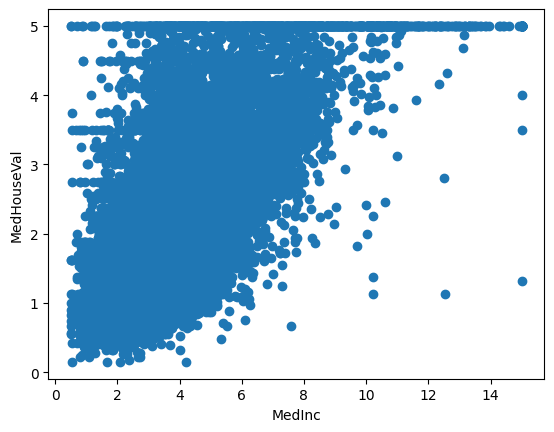

In [59]:
### YOUR CODE STARTS HERE ###

plt.scatter(x, y)
plt.xlabel('MedInc')
plt.ylabel('MedHouseVal')
plt.show()

### YOUR CODE ENDS HERE ###

### Stage 2: Model Training and Inference for Linear Regression [4 marks]

Q4: Fit a linear regressor on the data. Print the resultant slope and intercept. [2 marks]

In [60]:
### YOUR CODE STARTS HERE ###

# create a linear regression object
LR = LinearRegression()

# Reshape the data the 2D for model

x_2d = x.values.reshape(-1, 1)
y_2d = y.values.reshape(-1, 1)

# Fit the model
LR.fit(x_2d, y_2d)

# print the require intercept and coef.

print(LR.intercept_)
print(LR.coef_)

### YOUR CODE ENDS HERE ###

[0.45085577]
[[0.41793849]]


Q5: Visualize the linear regression result by plotting the regression line on top of the 2D scatter plot of `MedInc` and `MedHouseVal`. [2 marks]

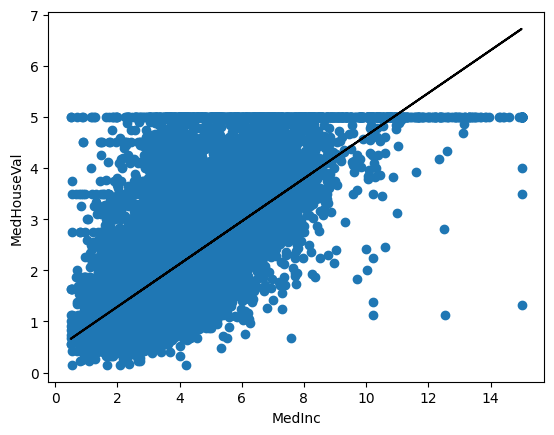

In [61]:
### YOUR CODE STARTS HERE ###

# First print the original plot
plt.scatter(x, y)
plt.xlabel('MedInc')
plt.ylabel('MedHouseVal')

# Add the linear line to this existing plot.

plt.plot(x_2d, 0.45085577 + 0.41793849*x_2d, 'black')
plt.show()


### YOUR CODE ENDS HERE ###

# Part 2: Logistic Regression [10 marks]

In [62]:
# imports
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import model_selection
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
%matplotlib inline

### Stage 1: Data Loading for Logistic Regression [6 marks]

In [63]:
# loading iris dataset
iris = datasets.load_iris()
print(iris)



{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

In [64]:
data=pd.DataFrame(iris['data'],columns=["Sepal Length","Sepal Width", "Petal length","Petal Width"])
data.head()

,Sepal Length,Sepal Width,Petal length,Petal Width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [65]:
data['Species']=iris['target']
data.head()


,Sepal Length,Sepal Width,Petal length,Petal Width,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [66]:
data['Species']=data['Species'].apply(lambda x: iris['target_names'][x])

In [67]:
data.info(100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal Length  150 non-null    float64
 1   Sepal Width   150 non-null    float64
 2   Petal length  150 non-null    float64
 3   Petal Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


Q6: Print the input and output features of 5 different samples from the data. [2 marks]

In [68]:
### YOUR CODE STARTS HERE ###

sample = data.sample(5, random_state = 44)
sample.head()
# print the input features
print(sample.drop(columns=['Species']))

# print the output features
print(sample['Species'])

### YOUR CODE ENDS HERE ###

     Sepal Length  Sepal Width  Petal length  Petal Width
144           6.7          3.3           5.7          2.5
9             4.9          3.1           1.5          0.1
79            5.7          2.6           3.5          1.0
95            5.7          3.0           4.2          1.2
104           6.5          3.0           5.8          2.2
144     virginica
9          setosa
79     versicolor
95     versicolor
104     virginica
Name: Species, dtype: object


Q7: Visualize the features using a pairplot. [2 marks]

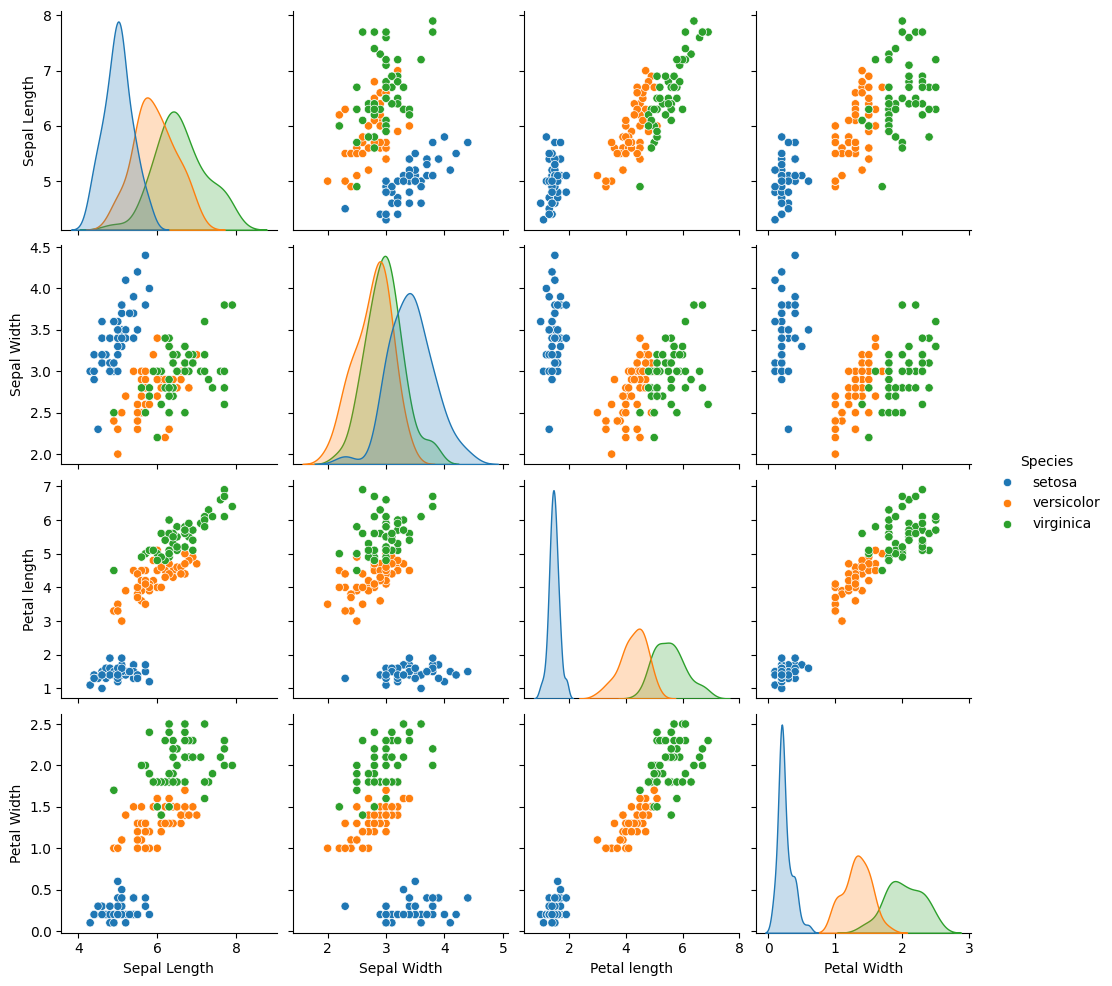

In [69]:
### YOUR CODE STARTS HERE ###

sns.pairplot(data, hue='Species')
plt.show()

### YOUR CODE ENDS HERE ###

In [70]:
data['Species']

,Species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa
...,...
145,virginica
146,virginica
147,virginica
148,virginica


Q8: Convert the labels into integer class values (0, 1, 2), and then remove the last class (verginica). [2 marks]

In [71]:
### YOUR CODE STARTS HERE ###

# create an object for label encoder and do the transform on species column
lc = LabelEncoder()
data['Species'] = lc.fit_transform(data['Species'])

# Just review the data for confirmation
display(data.sample(5))
print(dict(zip(lc.classes_, lc.transform(lc.classes_))))
print(data['Species'])

# Keep only 0, 1 and remove 2
data = data[data['Species'] != 2]
# Print unique value of species to verify

print(data['Species'].unique())

### YOUR CODE ENDS HERE ###

,Sepal Length,Sepal Width,Petal length,Petal Width,Species
114,5.8,2.8,5.1,2.4,2
70,5.9,3.2,4.8,1.8,1
9,4.9,3.1,1.5,0.1,0
17,5.1,3.5,1.4,0.3,0
59,5.2,2.7,3.9,1.4,1


{np.str_('setosa'): np.int64(0), np.str_('versicolor'): np.int64(1), np.str_('virginica'): np.int64(2)}
0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: Species, Length: 150, dtype: int64
[0 1]


### Stage 2: Data Splitting and Model Training for Logistic Regression [4 marks]

Q9: Split the data into x (input) and y (target). Further split x and y into training and testing subsets, with 80% samples for training and 20% samples for testing. [2 marks]

In [72]:
### YOUR CODE STARTS HERE ###

# First create x and y
x = data.drop(columns=['Species'])
y = data['Species']

 # create train test data
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)


### YOUR CODE ENDS HERE ###

Q10: Train a logistic regression model on the training subset. Print the weights and the bias. Predict the outputs using testing subset, and print the resultant accuracy. [2 marks]

In [73]:
### YOUR CODE STARTS HERE ###

# Creating a model object
LogReg_model = LogisticRegression()
LogReg_model.fit(x_train, y_train)

# calculate the

Coef = LogReg_model.coef_
Bias = LogReg_model.intercept_

y_pred = LogReg_model.predict(x_test)

print("Weight:", Coef)
print("Bias:", Bias)
print("Accuracy", accuracy_score(y_test, y_pred))

### YOUR CODE ENDS HERE ###

Weight: [[ 0.46248518 -0.84445753  2.21233212  0.92744332]]
Bias: [-6.52447541]
Accuracy 1.0


# Part 3: Support Vector Classifier [20 marks]

In [74]:
# imports
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn import model_selection
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
%matplotlib inline

### Stage 1: Data Preparation for Support Vector Classifier [6 marks]

In [75]:
# loading the dataset and normalize the features
iris = datasets.load_iris()

X = iris['data'][:,(2,3)]
Y = iris['target']
scaler = StandardScaler()
Xstan = scaler.fit_transform(X)
print(Y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


Q11: Take only two classes as targets, by removing all the samples belonging to the class "Verginica". Print any 5 samples from the data. [2 marks]

In [76]:
### YOUR CODE STARTS HERE ###
# Review scaler and Xstan #print all columns names:
print(scaler)
print(Xstan[0])
print(iris.feature_names)
print(iris.target_names)

# need to remove all samples related to Virginica class only
when_y_not_2 = (Y != 2)
print(len(when_y_not_2))
X_2 = Xstan[when_y_not_2]
Y_2 = Y[when_y_not_2]


new_iris = pd.DataFrame(X_2, columns=['petal length', 'petal width'])
new_iris['new_target'] = Y_2
random_sample = new_iris.sample(5)
print(random_sample)

### YOUR CODE ENDS HERE ###

StandardScaler()
[-1.34022653 -1.3154443 ]
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']
150
    petal length  petal width  new_target
60     -0.146641    -0.262387           1
84      0.421734     0.395774           1
20     -1.169714    -1.315444           0
37     -1.340227    -1.447076           0
77      0.705921     0.659038           1


Q12: Plot the input features as a 2D scatter plot. The two classes should be of shown with different colors. [2 marks]

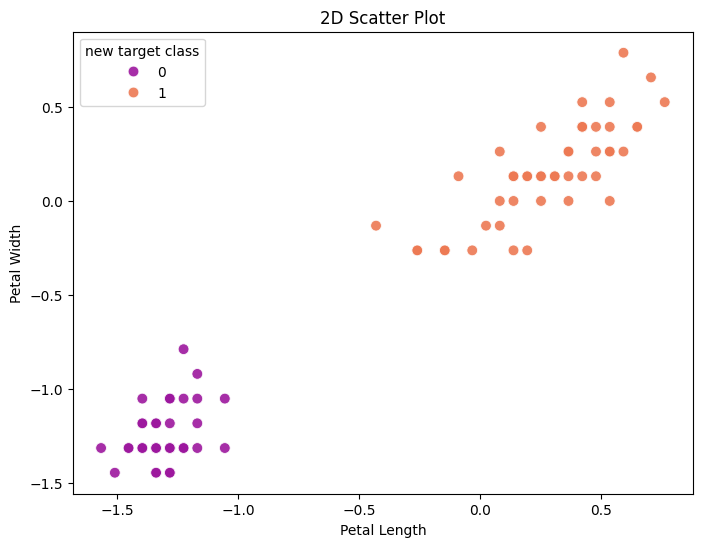

In [77]:
### YOUR CODE STARTS HERE ###

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=new_iris, x='petal length', y='petal width',
    hue='new_target',  palette='plasma',
    s=60, alpha=0.9
)

plt.title('2D Scatter Plot')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend(title='new target class')
plt.show()

### YOUR CODE ENDS HERE ###

Q13: Split the data into x (input) and y (target). Further split x and y into training and testing subsets, with 80% samples for training and 20% samples for testing. [2 marks]

In [78]:
### YOUR CODE STARTS HERE ###

x = new_iris.drop(columns=['new_target'])
y = new_iris['new_target']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### YOUR CODE ENDS HERE ###

### Stage 2: Model Training for Support Vector Classifier [14 marks]

Q14: Train a linear support vector classifier (with C=1 and hinge loss) on the training data. Plot the samples from the whole dataset, with decision boundary and margins (the two classes should have different colors). Predict on test set and print the resultant accuracy. [7 marks]

Accuracy for Linear SVC with C=1 : 1.0


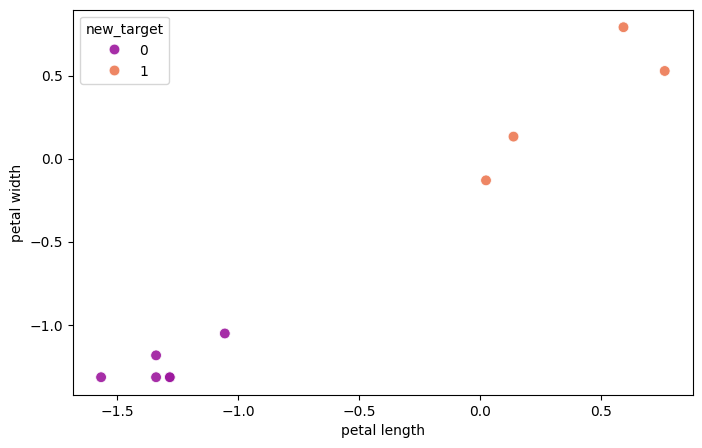

In [79]:
### YOUR CODE STARTS HERE ###

# Train a linear support vector classifier (with C=1 and hinge loss)
LSV_model_C_1 = LinearSVC(C=1, loss='hinge', random_state=42)
LSV_model_C_1.fit(x_train, y_train)

# Plot the samples (choosing 10 samples here) with decision boundary and margins
ten_samples = new_iris.sample(n=10, random_state=42)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=ten_samples, x='petal length', y='petal width',
    hue='new_target', palette='plasma', s=60, alpha=0.9
)

# Get the coefficients and intercept of the decision function
w = LSV_model_C_1.coef_[0]
b = LSV_model_C_1.intercept_[0]

# Predict on test set and print accuracy
y_pred_C_1 = LSV_model_C_1.predict(x_test)
accuracy_C_1 = accuracy_score(y_test, y_pred_C_1)
print(f"Accuracy for Linear SVC with C=1 : {accuracy_C_1}")


### YOUR CODE ENDS HERE ###

Q15: Train a linear support vector classifier (with C=1000 and hinge loss) on the training data. Plot the samples from the whole dataset, with decision boundary and margins (the two classes should have different colors). Predict on test set and print the resultant accuracy. [7 marks]

Accuracy for Linear SVC with C=1000 : 1.0


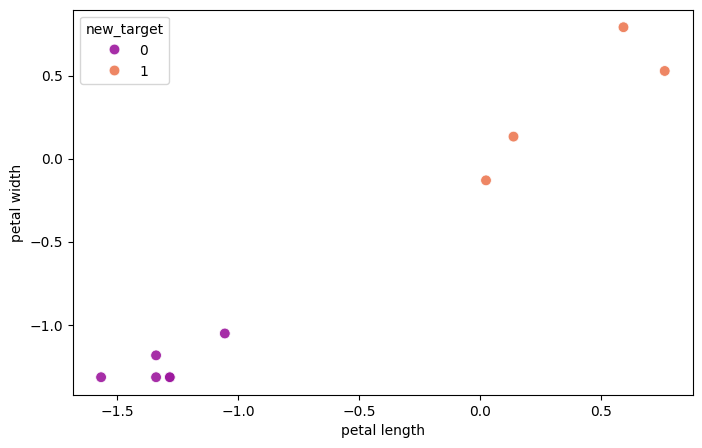

In [80]:
### YOUR CODE STARTS HERE ###

# Train a linear support vector classifier (with C=1 and hinge loss)
LSV_model_C_1000 = LinearSVC(C=1000, loss='hinge', random_state=42)
LSV_model_C_1000.fit(x_train, y_train)

# Plot the samples (choosing 10 samples here) with decision boundary and margins
ten_samples = new_iris.sample(n=10, random_state=42)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=ten_samples, x='petal length', y='petal width',
    hue='new_target', palette='plasma', s=60, alpha=0.9
)

# Get the coefficients and intercept of the decision function
w = LSV_model_C_1000.coef_[0]
b = LSV_model_C_1000.intercept_[0]

# Predict on test set and print accuracy
y_pred_C_1000 = LSV_model_C_1000.predict(x_test)
accuracy_C_1000 = accuracy_score(y_test, y_pred_C_1000)
print(f"Accuracy for Linear SVC with C=1000 : {accuracy_C_1000}")

### YOUR CODE ENDS HERE ###

# Part 4: Bagging [30 marks]

In [81]:
#imports
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

### Stage 1: Data Preparation for Bagging Implementation [5 marks]

In [82]:
# loading the dataset
def load_dataset():
  reg_x, reg_y = fetch_california_housing(return_X_y = True)

  print(reg_x)
  print(reg_y)

  print(reg_x.shape)
  print(reg_y.shape)

  reg_data = np.concatenate((reg_x, np.array(reg_y).reshape(-1, 1)), axis = 1)
  print(reg_data.shape)

  cols = ["feature"+str(i) for i in range(1, 9)]
  cols = cols + ["price(target)"]

  reg_dataset = pd.DataFrame(data = reg_data, columns = cols)
  print(reg_dataset)

  return reg_dataset

reg_dataset = load_dataset()
print("REGRESSION DATASET : \n", reg_dataset)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]
[4.526 3.585 3.521 ... 0.923 0.847 0.894]
(20640, 8)
(20640,)
(20640, 9)
       feature1  feature2  feature3  feature4  feature5  feature6  feature7  \
0        8.3252      41.0  6.984127  1.023810     322.0  2.555556     37.88   
1        8.3014      21.0  6.238137  0.971880    2401.0  2.109842     37.86   
2        7.2574      52.0  8.288136  1.073446     496.0  2.802260     37.85   
3        5.6431      52.0  5.817352  1.073059   

Q16: Write a method to get the random indices from train set, and then use the random indices to create a variation of the training set, where some samples are randomly repeated while others are not included. Split the data into x (input) and y (target), each split into training and testing subsets, with 80% samples for training and 20% samples for testing. [5 marks]

In [83]:
### YOUR CODE STARTS HERE ###

# Separate x and y
x = reg_dataset.drop(columns=['price(target)'])
y = reg_dataset['price(target)']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


def get_random_indices_and_variation(x_data, y_data):

    # Get random indices with replacement (bootstrapping)
    n_samples = x_data.shape[0]
    print(n_samples)
    random_indices = np.random.choice(n_samples, n_samples, replace=True)
    print(random_indices)

    # Use these random indices to create a variation of the training set
    x_variation = x_data.iloc[random_indices]
    y_variation = y_data.iloc[random_indices]

    return x_variation, y_variation


# Demonstrate the method
x_train_var, y_train_var = get_random_indices_and_variation(x_train, y_train)

# Display head of the varied training set to show it's different
print("\nHead of varied X_train_var:")
display(x_train_var.head())
print("\nHead of varied y_train_var:")
display(y_train_var.head())



### YOUR CODE ENDS HERE ###

16512
[13354  9560  7317 ...  3463  4393  9074]

Head of varied X_train_var:


,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8
3313,3.4187,17.0,10.053140,2.335749,889.0,2.147343,39.01,-122.75
5111,4.0625,48.0,5.961538,1.053254,1020.0,3.017751,33.96,-118.31
7062,5.2736,35.0,6.009732,1.012165,1386.0,3.372263,33.93,-118.03
9312,5.5791,32.0,6.610224,1.009585,1541.0,2.461661,37.99,-122.51
1736,4.5000,33.0,5.531100,0.909091,643.0,3.076555,37.97,-122.32



Head of varied y_train_var:


,price(target)
3313,2.005
5111,1.387
7062,1.795
9312,4.333
1736,1.566


### Stage 2: Training of Linear Regression Models for Bagging Implementation [15 marks]

Q17: Train a linear regression model on the training set with random indices, and print the mean squared error of the predictions on the test set. [3 marks]

In [84]:
### YOUR CODE STARTS HERE ###

LR_model_1 = LinearRegression()
LR_model_1.fit(x_train_var, y_train_var)

y_pred_1 = LR_model_1.predict(x_test)

mse_1 = mean_squared_error(y_test, y_pred_1)
print("mse_1:", mse_1)

### YOUR CODE ENDS HERE ###

mse_1: 0.5583125687498459


Q18: Fit a second linear regression model on a new variation of the training dataset with a new set of random indices, and print the mean squared error of the average of the predictions of the two linear regression models (this model and the model trianed in the previous question). [4 marks]

In [85]:
### YOUR CODE STARTS HERE ###


x_train_var_2, y_train_var_2 = get_random_indices_and_variation(x_train, y_train)

LR_model_2 = LinearRegression()
LR_model_2.fit(x_train_var_2, y_train_var_2)

y_pred_2 = LR_model_2.predict(x_test)

mse_2 = mean_squared_error(y_test, y_pred_2)
print("mse_2:", mse_2)

y_pred_avg = (y_pred_1 + y_pred_2) / 2
mse_avg_of_two = mean_squared_error(y_test, y_pred_avg)

print("mse_avg_two_models:", mse_avg_of_two)

### YOUR CODE ENDS HERE ###

16512
[ 9222 11378  5632 ...   991  6085  1721]
mse_2: 0.5527960231831612
mse_avg_two_models: 0.5552551595307461


Q19: Fit a third linear regression model on a new variation of the training dataset with a new set of random indices, and print the mean squared error of the average of the predictions of the three linear regression models (this model and the model trianed in the previous two questions). [4 marks]

In [86]:
### YOUR CODE STARTS HERE ###

x_train_var_3, y_train_var_3 = get_random_indices_and_variation(x_train, y_train)

LR_model_3 = LinearRegression()
LR_model_3.fit(x_train_var_3, y_train_var_3)

y_pred_3 = LR_model_3.predict(x_test)

mse_3 = mean_squared_error(y_test, y_pred_3)
print("mse_3:", mse_3)

y_pred_avg_three_models = (y_pred_1 + y_pred_2 + y_pred_3) / 3
mse_avg_three_models = mean_squared_error(y_test, y_pred_avg_three_models)

print("mse_avg_three_models:", mse_avg_three_models)

### YOUR CODE ENDS HERE ###



16512
[13618  3282 16220 ...  8726 10076  7806]
mse_3: 0.559234055097196
mse_avg_three_models: 0.5564144675228665


Q20: Fit a fourth linear regression model on a new variation of the training dataset with a new set of random indices, and print the mean squared error of the average of the predictions of the four linear regression models (this model and the model trianed in the previous three questions). [4 marks]

In [87]:
### YOUR CODE STARTS HERE ###

x_train_var_4, y_train_var_4 = get_random_indices_and_variation(x_train, y_train)

LR_model_4 = LinearRegression()
LR_model_4.fit(x_train_var_4, y_train_var_4)

y_pred_4 = LR_model_4.predict(x_test)

mse_4 = mean_squared_error(y_test, y_pred_4)
print("mse_4:", mse_4)

y_pred_avg_four_models = (y_pred_1 + y_pred_2 + y_pred_3 + y_pred_4) / 4
mse_avg_four_models = mean_squared_error(y_test, y_pred_avg_four_models)

print("mse_avg_four_models:", mse_avg_four_models)

### YOUR CODE ENDS HERE ###

16512
[12343 15054  1991 ...  7134 15423  2537]
mse_4: 0.5607083915855914
mse_avg_four_models: 0.5573989608592365


### Stage 3: Interative Variation in Bagging Implementation [10 marks]

Q21: Loop through using 2, 4, 6 ... 24 models and train the models with variations of the training dataset. Print the test mean squared error (take the average mean squared error of the corresponding 2, 4, 6 ... 24 models). Finally, plot the training loss and testing loss for all the cases (2, 4, 6 ... 24 models). [10 marks]

16512
[16275  4964  7278 ...  3217  7707  8787]
16512
[ 4744  3170 12685 ... 13774 10854  1789]
Number of models: 2, Test MSE of averaged predictions: 0.5628, Average Train MSE: 0.5176
16512
[ 4670  5811 11302 ... 12028 14176 14526]
16512
[15860  7457  2724 ...  2926  4410 14628]
16512
[ 8772 14629 16408 ... 10270 15063  1370]
16512
[ 9427    34  1265 ... 13485  3369  6490]
Number of models: 4, Test MSE of averaged predictions: 0.5520, Average Train MSE: 0.5222
16512
[15336 10162  3280 ...  3665  2189 13506]
16512
[ 9692  6241 14411 ...  2888  5409  8817]
16512
[15198 11393 10049 ...  8566 13574  9680]
16512
[ 7381 12518 12627 ... 12753  1676  3896]
16512
[ 1682  4597  2699 ...  8140 13086 10299]
16512
[11100 11809  4897 ... 14322  3644  1441]
Number of models: 6, Test MSE of averaged predictions: 0.5537, Average Train MSE: 0.5125
16512
[ 2045 10535  5717 ... 16251  6689  7979]
16512
[ 2701 15196 10038 ...  6983  5965  4940]
16512
[ 5045  9294  2614 ...  5913 14498  7993]
16512
[ 6767 

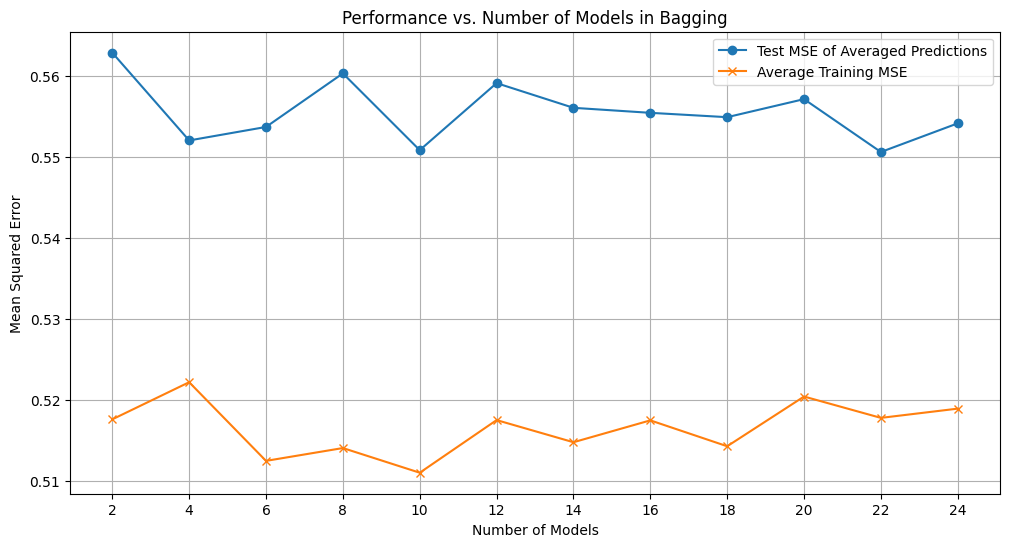

In [88]:
### YOUR CODE STARTS HERE ###

num_models_list = []
test_mse_avg_predictions = []
avg_train_mse = []

# Loop through using 2, 4, 6 and so on 24 models
for n_estimators in range(2, 25, 2):
    num_models_list.append(n_estimators)

    all_predictions = []
    train_mses = []

    for _ in range(n_estimators):
        # Get a new variation of the training data
        x_train_var_n, y_train_var_n = get_random_indices_and_variation(x_train, y_train)

        # Train a linear regression model
        lr_model_n = LinearRegression()
        lr_model_n.fit(x_train_var_n, y_train_var_n)

        # Make predictions on the test set
        y_pred_n = lr_model_n.predict(x_test)
        all_predictions.append(y_pred_n)

        # Calculate training MSE
        y_train_pred_n = lr_model_n.predict(x_train_var_n)
        train_mses.append(mean_squared_error(y_train_var_n, y_train_pred_n))

    # Calculate the average of the predictions from all models
    y_pred_avg_n = np.mean(all_predictions, axis=0)

    # Calculate the mean squared error for the averaged predictions
    mse_avg_n = mean_squared_error(y_test, y_pred_avg_n)
    test_mse_avg_predictions.append(mse_avg_n)

    # Calculate the average training MSE
    avg_train_mse.append(np.mean(train_mses))

    print(f"Number of models: {n_estimators}, Test MSE of averaged predictions: {mse_avg_n:.4f}, Average Train MSE: {np.mean(train_mses):.4f}")

# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(num_models_list, test_mse_avg_predictions, marker='o', label='Test MSE of Averaged Predictions')
plt.plot(num_models_list, avg_train_mse, marker='x', label='Average Training MSE')
plt.title('Performance vs. Number of Models in Bagging')
plt.xlabel('Number of Models')
plt.ylabel('Mean Squared Error')
plt.xticks(num_models_list)
plt.grid(True)
plt.legend()
plt.show()

# The Plot is at the end of all the iterations


# Part 5: K-Means Clustering [30 marks]

In [89]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import random
import collections
from sklearn.datasets import load_iris
import pandas as pd

### Stage 1: Data Preparation and Method Definitions for K-Means Clustering Implementation [18 marks]

In [90]:
# loading the dataset and creating the points
iris = load_iris(as_frame=True)
df = iris.frame

print(df)

data = df[['petal length (cm)', 'petal width (cm)']]

data.head()

print(data.head())

points=data.values.tolist()
points=np.array(points)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

     target  
0         0  

Q22: Write a method that takes a data point and a list of centroids, calculates the Euclidean distance between the point and each centroid, and returns the index of the closest centroid. [3 marks]

In [91]:
### YOUR CODE STARTS HERE ###


def closest_centroid(point, centroids):
    distances = [np.linalg.norm(point - centroid) for centroid in centroids]
    return int(np.argmin(distances))


### YOUR CODE ENDS HERE ###

Q23: Write a method that takes a dictionary mapping cluster IDs to lists of 2D data points, calculates the new centroid for each cluster by averaging its points, and returns the updated centroids as a NumPy array. [3 marks]

In [92]:
### YOUR CODE STARTS HERE ###


def update_centroids(clusters):
    return np.array([np.mean(points, axis=0) for points in clusters.values()])


### YOUR CODE ENDS HERE ###

Q24: Write a method that takes a random seed and an integer "p", sets the seed for reproducibility, and randomly selects "p" initial centroids from a globally defined points dataset, returning them as a NumPy array. [3 marks]

In [93]:
### YOUR CODE STARTS HERE ###

def initialize_centroids(seed, p):
    random.seed(seed)
    indices = random.sample(range(len(points)), p)
    return np.array([points[i] for i in indices])

### YOUR CODE ENDS HERE ###

Q25: Write a method that calculates the Sum of Squared Errors (SSE) for a clustering model. The function should take an array of centroids, a dictionary mapping cluster indices to lists of data points, and the total number of clusters "k", and return the sum of the squared Euclidean distances between every point and its assigned centroid. [3 marks]

In [94]:
### YOUR CODE STARTS HERE ###

def calculate_sse(centroids, clusters, k):
    sse = 0
    for i in range(k):
        for point in clusters[i]:
            sse += np.linalg.norm(point - centroids[i]) ** 2
    return sse


### YOUR CODE ENDS HERE ###

Q26: Write a method that implements the main K-means clustering loop. The function should take the number of clusters "p", a list of data points, and an array of initial centroids seed. It must iteratively assign each point to its nearest centroid, compute the new centroids, and repeat this process until convergence (when the centroids no longer change), ultimately returning the final centroids and a dictionary of the cluster assignments. Whenever kmeans needs to be implemented for any of the following questions, this kmeans implementation from scratch should be used. [6 marks]

In [95]:
### YOUR CODE STARTS HERE ###

def kmeans(p, data_points, centroids):
    while True:
        clusters = {i: [] for i in range(p)}
        for point in data_points:
            idx = closest_centroid(point, centroids)
            clusters[idx].append(point)

        new_centroids = update_centroids(clusters)

        if np.array_equal(new_centroids, centroids):
            break
        centroids = new_centroids

    return centroids, clusters

### YOUR CODE ENDS HERE ###

### Stage 2: Finding the Centroids using K-Means Clustering Implementation [12 marks]

Q27: Write a Python script that iterates over cluster counts from 1 to 4, executes the K-means algorithm using a fixed random seed of 42 for initialization, computes the Sum of Squared Errors (SSE) for each configuration, and returns the list of SSE values. Then plot the sum of squared distance in the y-axis and number of clusters in the x-axis. [6 marks]

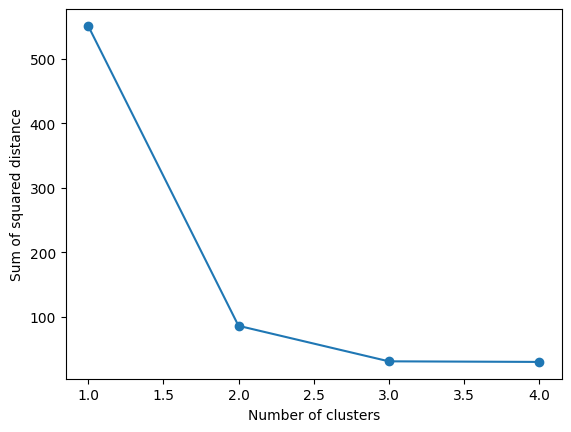

In [96]:
### YOUR CODE STARTS HERE ###

sse_values = []
for p in range(1, 5):
    initial_centroids = initialize_centroids(42, p)
    final_centroids, clusters = kmeans(p, points, initial_centroids)
    sse = calculate_sse(final_centroids, clusters, p)
    sse_values.append(sse)

plt.plot(range(1, 5), sse_values, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Sum of squared distance')
plt.show()

### YOUR CODE ENDS HERE ###

Q28: Use the best number of clusters from elbow method, and visualize the data after applying kmeans on the data using a 2D scatter plot. The two classes should be differently colored, and the centroids should also be shown. [6 marks]

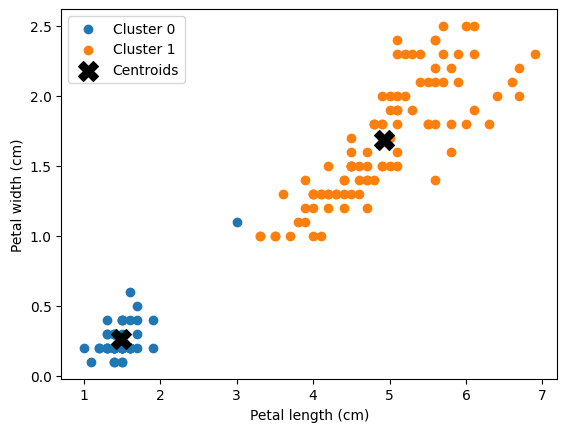

In [97]:
### YOUR CODE STARTS HERE ###

best_k = 2
initial_centroids = initialize_centroids(42, best_k)
final_centroids, clusters = kmeans(best_k, points, initial_centroids)

colors = ['tab:blue', 'tab:orange']
for i in range(best_k):
    cluster_points = np.array(clusters[i])
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=colors[i], label=f'Cluster {i}')

plt.scatter(final_centroids[:, 0], final_centroids[:, 1], c='black', marker='X', s=200, label='Centroids')
plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.legend()
plt.show()

### YOUR CODE ENDS HERE ###

In [98]:
# The assignment ends here